# Part 4: Results Visualization
We will look at the results from our modeling using plots to see how they performed.<br>
For both models (straight RF vs. GroupKFold), we will create a y_test vs. y_pred chart to see the accuracy of the model.<br>
We will also take a look at the top 15 MAGPIE features that the model found that correlate most to the predicted magnetic moment.<br>

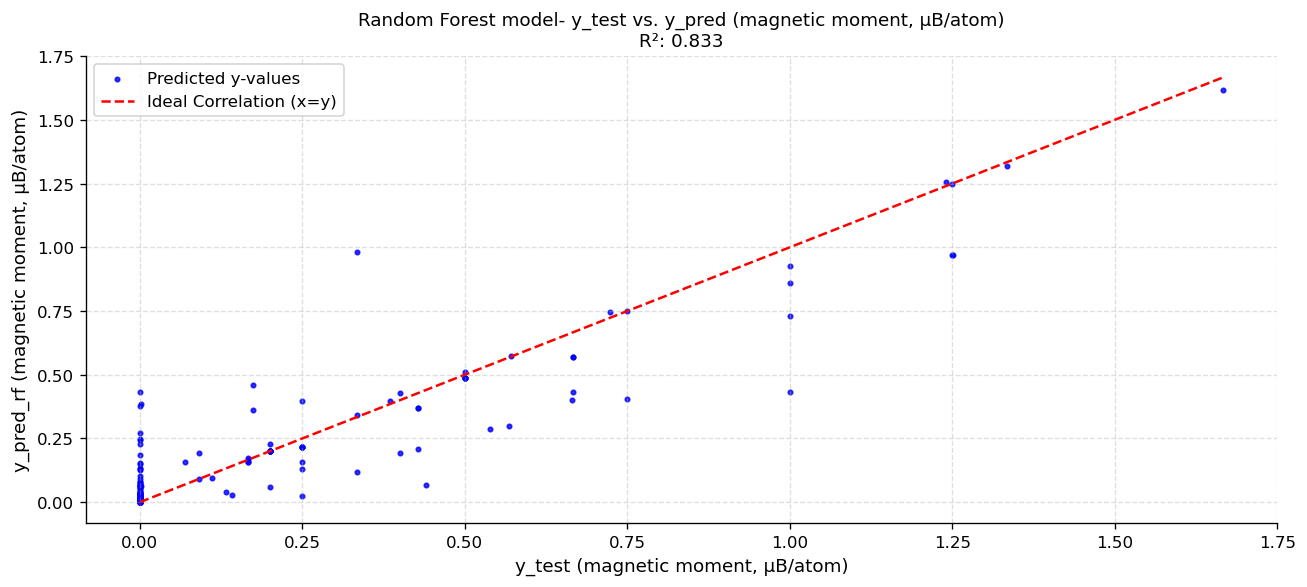

In [44]:
#First- take a look at how the RF model performs compared to the ideal.
fig, ax = plt.subplots(figsize=(11, 5))
ax.scatter(y_mag_test, y_mag_pred_rf, alpha=0.8, s=7, color='blue', label='Predicted y-values')

#Adding a 1:1 line from min to max of data
min_val = min(min(y_mag_test), min(y_mag_pred_rf))
max_val = max(max(y_mag_test), max(y_mag_pred_rf))
ax.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=1.5, label='Ideal Correlation (x=y)')

ax.set_xlabel('y_test (magnetic moment, µB/atom)', fontsize=11)
ax.set_ylabel('y_pred_rf (magnetic moment, µB/atom)', fontsize=11)
ax.set_title(f'Random Forest model- y_test vs. y_pred (magnetic moment, µB/atom)\nR\u00b2: {r2_rf:.3f}', fontsize=11)
ax.legend(loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, '04_y_pred_correlation_chart.png'), dpi=150, bbox_inches='tight')
plt.show()

=== Running 5-Fold GroupKFold Cross-Validation ===
Fold 1: MAE = 0.045 | RMSE = 0.103 | R² = 0.475
        Test Metals (3): ['Cd', 'Rh', 'Tc']
Fold 2: MAE = 0.189 | RMSE = 0.248 | R² = 0.215
        Test Metals (6): ['Nb', 'Os', 'Ta', 'Pd', 'Ru', 'V']
Fold 3: MAE = 0.215 | RMSE = 0.257 | R² = 0.323
        Test Metals (7): ['Cu', 'Mo', 'Y', 'Hf', 'Co', 'Sc', 'Hg']
Fold 4: MAE = 0.216 | RMSE = 0.376 | R² = 0.521
        Test Metals (7): ['Ni', 'Zn', 'Pt', 'W', 'Ag', 'Lu', 'Mn']
Fold 5: MAE = 0.242 | RMSE = 0.362 | R² = 0.517
        Test Metals (7): ['Zr', 'Ir', 'Re', 'Cr', 'Fe', 'Ti', 'Au']

Overall Out-of-Fold R² across all 5 groups: 0.511


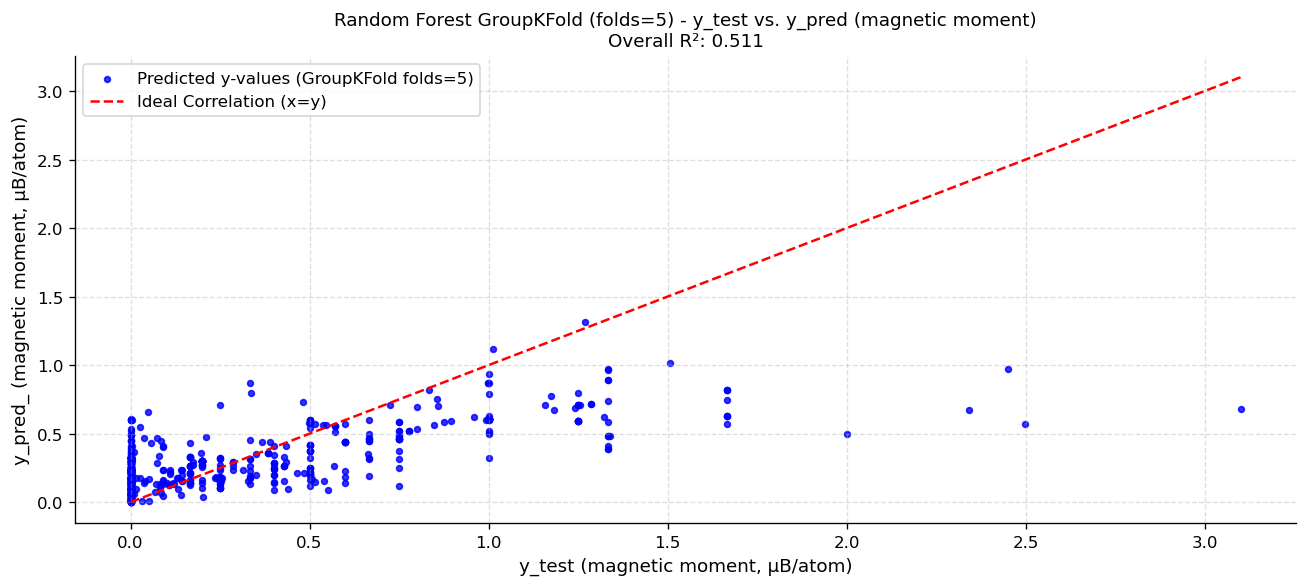

In [45]:
#Do the same- but adapted for the GroupKFold splits (Gemini helped me adapt this code)

#Storing predictions across all folds as their own array
oof_preds = np.zeros(len(mat_df))  # Out-Of-Fold predictions array
oof_indices = []

fold_mae, fold_rmse, fold_r2 = [], [], []

print("=== Running 5-Fold GroupKFold Cross-Validation ===")

#Do the GroupKFold again (we don't want to overwrite our original code)
for fold, (train_idx, test_idx) in enumerate(gkf.split(X_magpie, y_mag, groups=groups)):
    X_train_fold, X_test_fold = X_magpie.iloc[train_idx], X_magpie.iloc[test_idx]
    y_train_fold, y_test_fold = y_mag.iloc[train_idx], y_mag.iloc[test_idx]
    
    rf.fit(X_train_fold, y_train_fold)
    
    preds_fold = rf.predict(X_test_fold)
    
    #Store out-of-fold predictions
    oof_preds[test_idx] = preds_fold
    oof_indices.extend(test_idx)
    
    mae_kfold = mean_absolute_error(y_test_fold, preds_fold)
    rmse_kfold = np.sqrt(mean_squared_error(y_test_fold, preds_fold))
    r2_kfold = r2_score(y_test_fold, preds_fold)
    
    fold_mae.append(mae_kfold)
    fold_rmse.append(rmse_kfold)
    fold_r2.append(r2_kfold)
    
    test_metals = mat_df['tm_group'].iloc[test_idx].unique()
    print(f"Fold {fold+1}: MAE = {mae_kfold:.3f} | RMSE = {rmse_kfold:.3f} | R² = {r2_kfold:.3f}")
    print(f"        Test Metals ({len(test_metals)}): {list(test_metals)}")

#Combine all the predictions across the folds back together
y_true_gkf = y_mag.iloc[oof_indices]
y_pred_gkf = oof_preds[oof_indices]
overall_r2 = r2_score(y_true_gkf, y_pred_gkf)

print(f"\nOverall Out-of-Fold R² across all 5 groups: {overall_r2:.3f}")

#Now do all of those in 1 big plot (just copy the code from above)
fig, ax = plt.subplots(figsize=(11, 5))
ax.scatter(y_true_gkf, y_pred_gkf, alpha=0.8, s=12, color='blue', label='Predicted y-values (GroupKFold folds=5)')
min_val = min(min(y_true_gkf), min(y_pred_gkf))
max_val = max(max(y_true_gkf), max(y_pred_gkf))
ax.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=1.5, label='Ideal Correlation (x=y)')
ax.set_xlabel('y_test (magnetic moment, μB/atom)', fontsize=11)
ax.set_ylabel('y_pred_ (magnetic moment, μB/atom)', fontsize=11)
ax.set_title(f"Random Forest GroupKFold (folds=5) - y_test vs. y_pred (magnetic moment)\nOverall R²: {overall_r2:.3f}", fontsize=11)

ax.legend(loc='upper left')
plt.tight_layout()

# Save & Show
plt.savefig(os.path.join(output_dir, '04_gkf_y_pred_chart.png'), dpi=150, bbox_inches='tight')
plt.show()

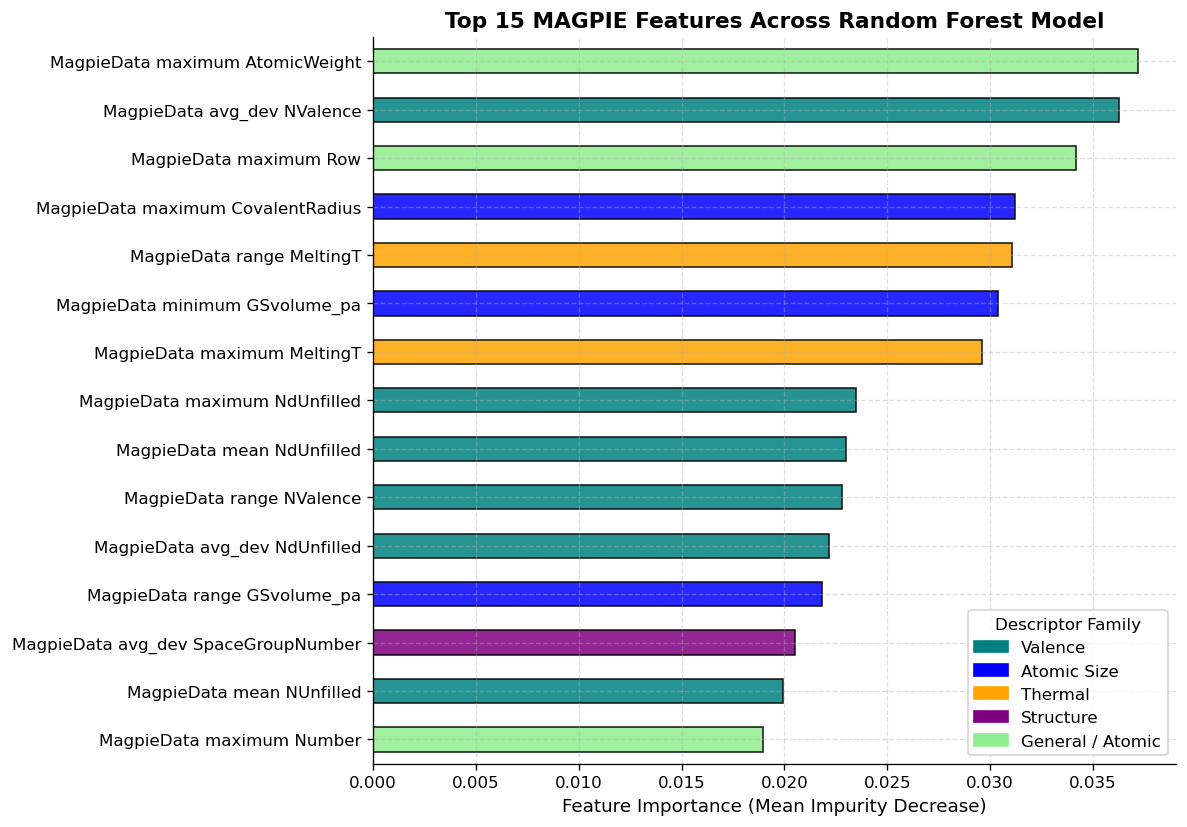

Top 10 features across Random Forest Model:
MagpieData maximum AtomicWeight      0.0372
MagpieData avg_dev NValence          0.0363
MagpieData maximum Row               0.0342
MagpieData maximum CovalentRadius    0.0312
MagpieData range MeltingT            0.0311
MagpieData minimum GSvolume_pa       0.0304
MagpieData maximum MeltingT          0.0296
MagpieData maximum NdUnfilled        0.0235
MagpieData mean NdUnfilled           0.0230
MagpieData range NValence            0.0228


In [52]:
#I want to adapt the code from week 5 D2 to show the top 15 MAGPIE features- but Gemini showed me it is much harder than just changing a few variables.
#So will basically write from scratch with its help
#MAGPIE has magnetic moment in it.  I needed to remove it so we're not correlating the property with itself
magpie_cols = [c for c in mat_df.columns if 'MagpieData' in c and 'GSmagmom' not in c]
X_magpie = mat_df[magpie_cols]

#Because we took out magnetic moments we have to re-fit (Gemini helped me find)
rf.fit(X_magpie, y_mag)

importances = pd.Series(rf.feature_importances_, index=magpie_cols).sort_values(ascending=False)
top15_importances = importances.head(15)
#If we were doing this over multiple folds, we would have error bars- but you can't do that.

#Color over MAGPIE Descriptor families (makes it easier to see, plus the paper wants that) (Gemini helped me)
family_colors = {
    'Valence': 'teal',       
    'Atomic Size': 'blue',    
    'Thermal': 'orange',        
    'Structure': 'purple',      
    'General / Atomic': 'lightgreen'
}

# Function to assign a family based on feature name keyword
def get_feature_family(feature_name):
    if any(k in feature_name for k in ['Valence', 'Unfilled']):
        return 'Valence'
    elif any(k in feature_name for k in ['Radius', 'Volume', 'GSvolume']):
        return 'Atomic Size'
    elif any(k in feature_name for k in ['Melting', 'Thermal']):
        return 'Thermal'
    elif any(k in feature_name for k in ['SpaceGroup']):
        return 'Structure'
    else:
        return 'General / Atomic'

#Pass bar colors to a variable
bar_colors = [family_colors[get_feature_family(feat)] for feat in top15_importances.index]

#Plot for importance
fig, ax = plt.subplots(figsize=(10, 7))

top15_importances.plot(
    kind='barh', 
    ax=ax, 
    color=bar_colors,
    edgecolor='black',
    alpha=0.85
)

#Gemini helped me find what to import here to make the legend I needed
import matplotlib.patches as mpatches
legend_handles = [
    mpatches.Patch(color=color, label=family) 
    for family, color in family_colors.items()
    if any(get_feature_family(feat) == family for feat in top15_importances.index)
]
ax.legend(handles=legend_handles, title="Descriptor Family", loc='lower right')

ax.invert_yaxis()
ax.set_xlabel('Feature Importance (Mean Impurity Decrease)', fontsize=11)
ax.set_title('Top 15 MAGPIE Features Across Random Forest Model', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, '04_feature_importance.png'), dpi=150, bbox_inches='tight')
plt.show()

print('Top 10 features across Random Forest Model:')
print(top15_importances.head(10).round(4).to_string())